# HOM Temporal Validation Plots

This notebook is plotting-only. It reads CSV files produced by `run_hom_three_overlap_batch.py` and does not run the simulation.

Default dataset: `results/hom_config`, generated from `configs/hom_config.ini`.

In [1]:
from pathlib import Path
import configparser

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'sequence').is_dir() and (path / 'example').is_dir():
            return path
    raise RuntimeError('Could not find repo root. Run this notebook from inside the repository.')

REPO_ROOT = find_repo_root()
EXAMPLE_DIR = REPO_ROOT / 'example' / 'hom_swapping_validation'

CONFIG_NAME = 'hom_config'
CONFIG_PATH = EXAMPLE_DIR / 'configs' / f'{CONFIG_NAME}.ini'
RESULTS_DIR = EXAMPLE_DIR / 'results' / CONFIG_NAME

print('Config:', CONFIG_PATH.relative_to(REPO_ROOT))
print('Results:', RESULTS_DIR.relative_to(REPO_ROOT))


Config: example\hom_swapping_validation\configs\hom_config.ini
Results: example\hom_swapping_validation\results\hom_config


In [2]:
config = configparser.ConfigParser(inline_comment_prefixes=(';', '#'))
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Missing config file: {CONFIG_PATH}')
config.read_string(CONFIG_PATH.read_text(encoding='utf-8-sig'))

def cfg_float(section: str, key: str, default: float) -> float:
    return config.getfloat(section, key, fallback=default)

def load_csv(name: str) -> pd.DataFrame:
    path = RESULTS_DIR / name
    if not path.exists():
        raise FileNotFoundError(f'Missing {path}. Run the batch script first for CONFIG_NAME={CONFIG_NAME!r}.')
    return pd.read_csv(path)

runs = load_csv('hom_temporal_runs.csv')
summary = load_csv('hom_temporal_delay_scan_validation.csv')

DURATION_S = cfg_float('batch', 'duration_s', 1.0)
RUNS_PER_POINT = config.getint('batch', 'runs_per_point', fallback=int(runs['run_index'].nunique()))
SOURCE_FREQUENCY_HZ = cfg_float('source', 'source_frequency_hz', float('nan'))

print(f'raw runs: {len(runs)}')
print(f'delay points: {runs["delay_ps"].nunique()}')
print(f'runs per point in config: {RUNS_PER_POINT}')
print(f'simulated duration per run: {DURATION_S:g} s')
print(f'source frequency: {SOURCE_FREQUENCY_HZ:g} Hz')
summary.head()


raw runs: 810
delay points: 81
runs per point in config: 10
simulated duration per run: 1 s
source frequency: 8e+07 Hz


,delay_ps,runs,pulses_per_run,total_pulses,source_frequency_hz,duration_per_run_s,total_duration_s,bsm1_count,bsm2_count,heraldA_count,heraldB_count,heraldA_0_count,heraldA_1_count,heraldB_0_count,heraldB_1_count,bsm_twofold_count,hom_fourfold_count,selected_herald_fourfold_count,hh_herald_fourfold_count,hv_herald_fourfold_count,vh_herald_fourfold_count,vv_herald_fourfold_count,matched_herald_fourfold_count,mismatched_herald_fourfold_count,matched_projected_interfering_pairs,mismatched_projected_interfering_pairs,matched_projected_coincidence_count,mismatched_projected_coincidence_count,hh_channel_projected_pairs,hv_channel_projected_pairs,vh_channel_projected_pairs,vv_channel_projected_pairs,matched_channel_projected_pairs,mismatched_channel_projected_pairs,matched_channel_projected_coincidence_count,mismatched_channel_projected_coincidence_count,interfering_pairs,interfering_coincidence_count,interfering_bunch_count,mean_total_overlap,mean_temporal_overlap,mean_spectral_overlap,mean_polarization_overlap,matched_channel_mean_polarization_overlap,mismatched_channel_mean_polarization_overlap,bsm_twofold_rate_per_pulse,bsm_twofold_count_per_s,hom_fourfold_rate_per_pulse,hom_fourfold_count_per_s,selected_herald_fourfold_rate_per_pulse,selected_herald_fourfold_count_per_s,matched_herald_fourfold_rate_per_pulse,matched_herald_fourfold_count_per_s,mismatched_herald_fourfold_rate_per_pulse,mismatched_herald_fourfold_count_per_s,matched_projected_coincidence_rate_per_pulse,matched_projected_coincidence_count_per_s,mismatched_projected_coincidence_rate_per_pulse,mismatched_projected_coincidence_count_per_s,interfering_coincidence_rate_per_pulse,interfering_coincidence_count_per_s,matched_projected_coincidence_prob,mismatched_projected_coincidence_prob,matched_channel_projected_coincidence_prob,mismatched_channel_projected_coincidence_prob,interfering_coincidence_prob,fiber_dcd_a_ps_per_nm_km,fiber_dcd_b_ps_per_nm_km,raman_noise_rate_total_hz,heraldA_offset_ps_used,heraldB_offset_ps_used,herald_basis,herald_channel_a,herald_channel_b
0,-800,10,80000000,800000000,80000000.0,1.0,10.0,3025848,3027725,7462242,7461314,3731814,3730428,3731371,3729943,17185,5055,1286,1286,1304,1310,1250,2536,2614,6426,6300,3205,3255,2858,2734,2773,2711,5569,5507,2761,2811,12726,6460,6266,7.913011e-39,1.453587e-38,1.0,0.504990,1.0,0.0,0.000021,1718.5,0.000006,505.5,0.000002,128.6,0.000003,253.6,0.000003,261.4,0.000004,320.5,0.000004,325.5,0.000008,646.0,0.498755,0.516667,0.495780,0.510441,0.507622,13.703052,13.703052,0.0,-97937635,-97937635,Z,0,0
1,-780,10,80000000,800000000,80000000.0,1.0,10.0,3022786,3025053,7458616,7458358,3729920,3728696,3728284,3730074,16880,4984,1299,1299,1294,1251,1224,2523,2545,6305,6371,3120,3171,2780,2789,2740,2705,5485,5529,2706,2728,12676,6291,6385,5.488541e-37,1.074954e-36,1.0,0.497436,1.0,0.0,0.000021,1688.0,0.000006,498.4,0.000002,129.9,0.000003,252.3,0.000003,254.5,0.000004,312.0,0.000004,317.1,0.000008,629.1,0.494845,0.497724,0.493345,0.493398,0.496292,13.703052,13.703052,0.0,-97937635,-97937635,Z,0,0
2,-760,10,80000000,800000000,80000000.0,1.0,10.0,3022041,3022077,7459585,7460329,3732276,3727309,3730993,3729336,16815,5051,1317,1317,1299,1241,1290,2607,2540,6337,6300,3207,3164,2781,2758,2681,2735,5516,5439,2798,2749,12637,6371,6266,3.384711e-35,7.079748e-35,1.0,0.501543,1.0,0.0,0.000021,1681.5,0.000006,505.1,0.000002,131.7,0.000003,260.7,0.000003,254.0,0.000004,320.7,0.000004,316.4,0.000008,637.1,0.506075,0.502222,0.507252,0.505424,0.504154,13.703052,13.703052,0.0,-97937635,-97937635,Z,0,0
3,-740,10,80000000,800000000,80000000.0,1.0,10.0,3025068,3023245,7461693,7461407,3732779,3728914,3730941,3730466,16752,4989,1299,1299,1223,1304,1262,2561,2527,6331,6158,3155,3103,2731,2674,2702,2759,5490,5376,2728,2703,12489,6258,6231,2.018493e-33,4.141171e-33,1.0,0.506926,1.0,0.0,0.000021,1675.2,0.000006,498.9,0.000002,129.9,0.000003,256.1,0.000003,252.7,0.000004,315.5,0.000004,310.3,0.000008,625.8,0.498341,0.503897,0.496903,0.502790,0.50108

In [3]:
# Convert raw per-run counts to counts/s so error bars are computed across Monte Carlo runs.
count_columns = [
    'bsm1_count',
    'bsm2_count',
    'heraldA_count',
    'heraldB_count',
    'bsm_twofold_count',
    'hom_fourfold_count',
    'selected_herald_fourfold_count',
    'matched_herald_fourfold_count',
    'mismatched_herald_fourfold_count',
    'matched_projected_coincidence_count',
    'mismatched_projected_coincidence_count',
    'interfering_coincidence_count',
]

for col in count_columns:
    if col in runs.columns:
        runs[f'{col}_per_s'] = runs[col] / DURATION_S

rate_columns = [f'{col}_per_s' for col in count_columns if f'{col}_per_s' in runs.columns]

agg = runs.groupby('delay_ps')[rate_columns].agg(['mean', 'std', 'count']).reset_index()
agg.columns = ['_'.join([str(x) for x in col if str(x)]) for col in agg.columns.to_flat_index()]
agg = agg.sort_values('delay_ps').reset_index(drop=True)

def y_mean(col: str) -> np.ndarray:
    return agg[f'{col}_per_s_mean'].to_numpy(float)

def y_std(col: str) -> np.ndarray:
    return agg[f'{col}_per_s_std'].fillna(0).to_numpy(float)

delay = agg['delay_ps'].to_numpy(float)
agg.head()


,delay_ps,bsm1_count_per_s_mean,bsm1_count_per_s_std,bsm1_count_per_s_count,bsm2_count_per_s_mean,bsm2_count_per_s_std,bsm2_count_per_s_count,heraldA_count_per_s_mean,heraldA_count_per_s_std,heraldA_count_per_s_count,heraldB_count_per_s_mean,heraldB_count_per_s_std,heraldB_count_per_s_count,bsm_twofold_count_per_s_mean,bsm_twofold_count_per_s_std,bsm_twofold_count_per_s_count,hom_fourfold_count_per_s_mean,hom_fourfold_count_per_s_std,hom_fourfold_count_per_s_count,selected_herald_fourfold_count_per_s_mean,selected_herald_fourfold_count_per_s_std,selected_herald_fourfold_count_per_s_count,matched_herald_fourfold_count_per_s_mean,matched_herald_fourfold_count_per_s_std,matched_herald_fourfold_count_per_s_count,mismatched_herald_fourfold_count_per_s_mean,mismatched_herald_fourfold_count_per_s_std,mismatched_herald_fourfold_count_per_s_count,matched_projected_coincidence_count_per_s_mean,matched_projected_coincidence_count_per_s_std,matched_projected_coincidence_count_per_s_count,mismatched_projected_coincidence_count_per_s_mean,mismatched_projected_coincidence_count_per_s_std,mismatched_projected_coincidence_count_per_s_count,interfering_coincidence_count_per_s_mean,interfering_coincidence_count_per_s_std,interfering_coincidence_count_per_s_count
0,-800,302584.8,462.806607,10,302772.5,592.042650,10,746224.2,875.121934,10,746131.4,999.248740,10,1718.5,30.222324,10,505.5,19.190565,10,128.6,10.426462,10,253.6,9.335714,10,261.4,14.167255,10,320.5,7.735201,10,325.5,15.529542,10,646.0,21.587033,10
1,-780,302278.6,562.559666,10,302505.3,586.158312,10,745861.6,443.196771,10,745835.8,505.609599,10,1688.0,46.188022,10,498.4,23.257974,10,129.9,12.178761,10,252.3,21.018775,10,254.5,13.142383,10,312.0,19.933222,10,317.1,9.314863,10,629.1,21.926392,10
2,-760,302204.1,470.877066,10,302207.7,664.015738,10,745958.5,1069.236929,10,746032.9,790.185555,10,1681.5,35.154421,10,505.1,16.508920,10,131.7,12.875903,10,260.7,13.021777,10,254.0,15.613385,10,320.7,13.350406,10,316.4,15.313030,10,637.1,13.211527,10
3,-740,302506.8,555.228642,10,302324.5,403.220163,10,746169.3,757.182357,10,746140.7,700.822382,10,1675.2,30.113858,10,498.9,15.996180,10,129.9,10.754327,10,256.1,16.044729,10,252.7,16.303033,10,315.5,16.965652,10,310.3,15.107393,10,625.8,17.125679,10
4,-720,302367.6,599.206920,10,302292.2,479.708662,10,745604.5,653.676823,10,745836.9,681.262953,10,1700.5,35.898777,10,500.4,14.253265,10,130.1,7.992357,10,262.0,12.220202,10,248.6,11.815244,10,320.8,12.254704,10,304.9,9.362455,10,625.7,16.438775,10


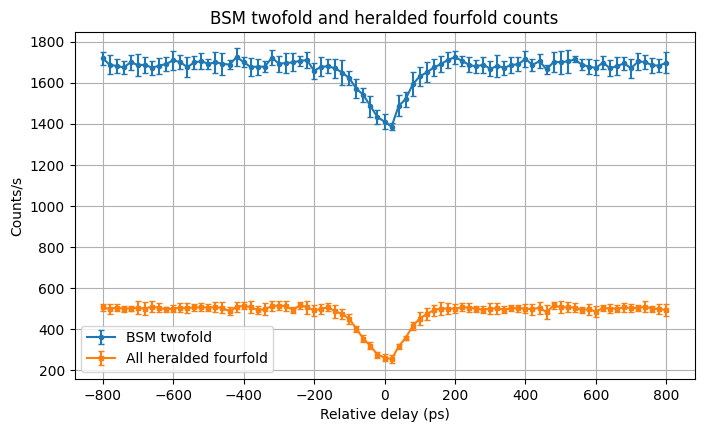

In [4]:
fig, ax = plt.subplots()
ax.errorbar(delay, y_mean('bsm_twofold_count'), yerr=y_std('bsm_twofold_count'), marker='o', ms=3, lw=1.5, capsize=2, label='BSM twofold')
ax.errorbar(delay, y_mean('hom_fourfold_count'), yerr=y_std('hom_fourfold_count'), marker='s', ms=3, lw=1.5, capsize=2, label='All heralded fourfold')
ax.set_xlabel('Relative delay (ps)')
ax.set_ylabel('Counts/s')
ax.set_title('BSM twofold and heralded fourfold counts')
ax.legend()
plt.show()


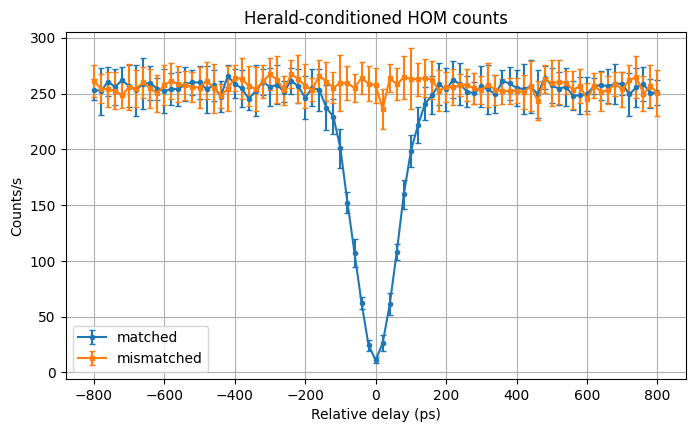

In [5]:
fig, ax = plt.subplots()
ax.errorbar(delay, y_mean('matched_herald_fourfold_count'), yerr=y_std('matched_herald_fourfold_count'), marker='o', ms=3, lw=1.5, capsize=2, label='matched')
ax.errorbar(delay, y_mean('mismatched_herald_fourfold_count'), yerr=y_std('mismatched_herald_fourfold_count'), marker='s', ms=3, lw=1.5, capsize=2, label='mismatched')
ax.set_xlabel('Relative delay (ps)')
ax.set_ylabel('Counts/s')
ax.set_title('Herald-conditioned HOM counts')
ax.legend()
plt.show()


In [6]:
# Visibility estimate from measured matched fourfold counts/s.
# Baseline is estimated from the outer 20% of absolute delay values; dip minimum is the point nearest zero delay.
matched = y_mean('matched_herald_fourfold_count')
abs_delay = np.abs(delay)
edge_mask = abs_delay >= 0.8 * abs_delay.max()
zero_idx = int(np.argmin(abs_delay))

baseline = float(np.mean(matched[edge_mask]))
dip = float(matched[zero_idx])
visibility = (baseline - dip) / baseline if baseline > 0 else np.nan

print(f'Baseline matched fourfold rate: {baseline:.3f} counts/s')
print(f'Near-zero-delay matched fourfold rate: {dip:.3f} counts/s at delay={delay[zero_idx]:.0f} ps')
print(f'Estimated HOM visibility: {100 * visibility:.2f}%')


Baseline matched fourfold rate: 256.133 counts/s
Near-zero-delay matched fourfold rate: 11.100 counts/s at delay=0 ps
Estimated HOM visibility: 95.67%


In [7]:
# Inspect the final aggregated CSV generated by the batch script.
summary[['delay_ps', 'runs', 'total_duration_s', 'bsm_twofold_count_per_s', 'hom_fourfold_count_per_s', 'matched_herald_fourfold_count_per_s', 'mismatched_herald_fourfold_count_per_s']].head(10)


,delay_ps,runs,total_duration_s,bsm_twofold_count_per_s,hom_fourfold_count_per_s,matched_herald_fourfold_count_per_s,mismatched_herald_fourfold_count_per_s
0,-800,10,10.0,1718.5,505.5,253.6,261.4
1,-780,10,10.0,1688.0,498.4,252.3,254.5
2,-760,10,10.0,1681.5,505.1,260.7,254.0
3,-740,10,10.0,1675.2,498.9,256.1,252.7
4,-720,10,10.0,1700.5,500.4,262.0,248.6
5,-700,10,10.0,1685.8,503.8,256.8,256.1
6,-680,10,10.0,1687.7,499.3,253.2,254.5
7,-660,10,10.0,1673.6,510.0,259.0,260.0
8,-640,10,10.0,1683.2,503.6,259.4,254.6
9,-620,10,10.0,1691.5,495.8,254.4,250.2


## BSM-Only Results

This section reads `results/hom_bsm_only_config`. In this mode the idlers are not projected or detected; they are routed to passive sinks. The only operational observable plotted here is the BSM-side twofold coincidence rate.

In [8]:
BSM_ONLY_CONFIG_NAME = 'hom_bsm_only_config'
BSM_ONLY_RESULTS_DIR = EXAMPLE_DIR / 'results' / BSM_ONLY_CONFIG_NAME

def load_bsm_only_csv(name: str) -> pd.DataFrame:
    path = BSM_ONLY_RESULTS_DIR / name
    if not path.exists():
        raise FileNotFoundError(f'Missing {path}. Run the BSM-only batch config first.')
    df = pd.read_csv(path)
    if 'herald_mode' in df.columns and set(df['herald_mode'].dropna().unique()) != {'bsm_only'}:
        raise ValueError(f'{path} does not look like BSM-only output.')
    return df

bsm_temporal = load_bsm_only_csv('hom_temporal_runs.csv')
bsm_polarization = load_bsm_only_csv('hom_polarization_runs.csv')
bsm_spectral = load_bsm_only_csv('hom_spectral_runs.csv')

print('BSM-only result directory:', BSM_ONLY_RESULTS_DIR.relative_to(REPO_ROOT))
print('temporal rows:', len(bsm_temporal))
print('polarization rows:', len(bsm_polarization))
print('spectral rows:', len(bsm_spectral))


BSM-only result directory: example\hom_swapping_validation\results\hom_bsm_only_config
temporal rows: 310
polarization rows: 310
spectral rows: 310


In [9]:
def summarize_bsm_only(df: pd.DataFrame, x_col: str) -> pd.DataFrame:
    if 'duration_per_run_s' in df.columns:
        duration = df['duration_per_run_s'].astype(float)
    else:
        duration = DURATION_S
    work = df.copy()
    work['bsm_twofold_count_per_s'] = work['bsm_twofold_count'].astype(float) / duration
    out = (
        work.groupby(x_col, sort=True)['bsm_twofold_count_per_s']
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .sort_values(x_col)
    )
    out['std'] = out['std'].fillna(0.0)
    return out

bsm_temporal_summary = summarize_bsm_only(bsm_temporal, 'delay_ps')
bsm_polarization_summary = summarize_bsm_only(bsm_polarization, 'angle_deg')
bsm_spectral_summary = summarize_bsm_only(bsm_spectral, 'detuning_nm')

bsm_temporal_summary.head()


,delay_ps,mean,std,count
0,-800,1906.8,48.428183,10
1,-747,1885.6,46.857230,10
2,-694,1866.5,52.938644,10
3,-640,1864.3,56.866413,10
4,-587,1898.7,40.647673,10


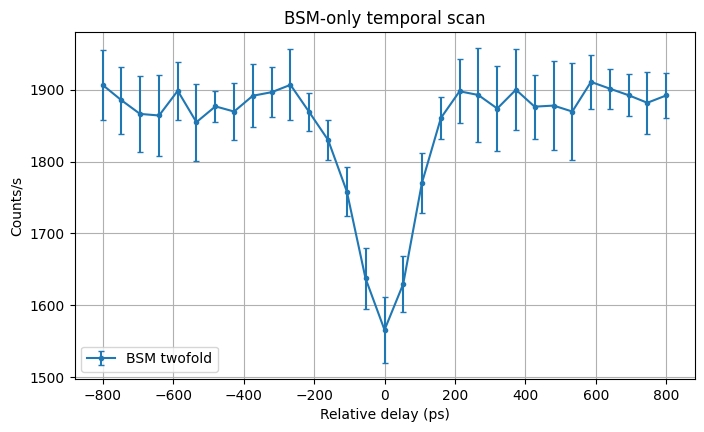

In [10]:
fig, ax = plt.subplots()
ax.errorbar(
    bsm_temporal_summary['delay_ps'],
    bsm_temporal_summary['mean'],
    yerr=bsm_temporal_summary['std'],
    marker='o',
    ms=3,
    lw=1.5,
    capsize=2,
    label='BSM twofold',
)
ax.set_xlabel('Relative delay (ps)')
ax.set_ylabel('Counts/s')
ax.set_title('BSM-only temporal scan')
ax.legend()
plt.show()


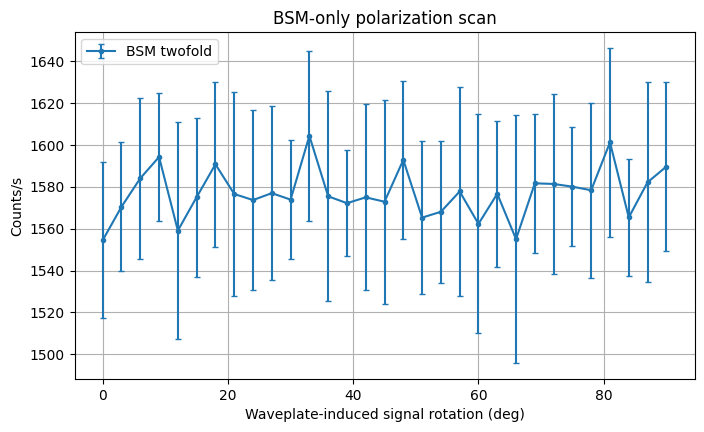

In [11]:
fig, ax = plt.subplots()
ax.errorbar(
    bsm_polarization_summary['angle_deg'],
    bsm_polarization_summary['mean'],
    yerr=bsm_polarization_summary['std'],
    marker='o',
    ms=3,
    lw=1.5,
    capsize=2,
    label='BSM twofold',
)
ax.set_xlabel('Waveplate-induced signal rotation (deg)')
ax.set_ylabel('Counts/s')
ax.set_title('BSM-only polarization scan')
ax.legend()
plt.show()


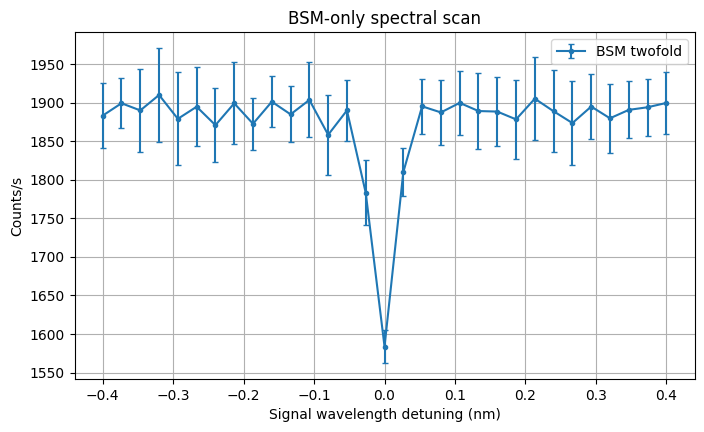

In [12]:
fig, ax = plt.subplots()
ax.errorbar(
    bsm_spectral_summary['detuning_nm'],
    bsm_spectral_summary['mean'],
    yerr=bsm_spectral_summary['std'],
    marker='o',
    ms=3,
    lw=1.5,
    capsize=2,
    label='BSM twofold',
)
ax.set_xlabel('Signal wavelength detuning (nm)')
ax.set_ylabel('Counts/s')
ax.set_title('BSM-only spectral scan')
ax.legend()
plt.show()


In [13]:
# Compact table for quick inspection. With runs_per_point=1, std is zero by construction.
print('Temporal BSM-only twofold range:')
print(bsm_temporal_summary[['delay_ps', 'mean', 'std', 'count']].head().to_string(index=False))
print('...')
print(bsm_temporal_summary[['delay_ps', 'mean', 'std', 'count']].tail().to_string(index=False))


Temporal BSM-only twofold range:
 delay_ps   mean       std  count
     -800 1906.8 48.428183     10
     -747 1885.6 46.857230     10
     -694 1866.5 52.938644     10
     -640 1864.3 56.866413     10
     -587 1898.7 40.647673     10
...
 delay_ps   mean       std  count
      586 1911.1 37.663569     10
      640 1901.6 27.929276     10
      693 1892.5 29.523061     10
      746 1882.0 43.443450     10
      800 1892.3 31.819107     10
